In [1]:
import sys
import os
import numpy as np
from tdaphantom.tdaphantom import Phantom
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-dark')


## Generate data

In [2]:
def _make_disk(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    pts = []
    while len(pts) < n:
        b = rng.uniform(-1, 1, (n * 4, 2))
        pts.append(b[np.linalg.norm(b, axis=1) <= 1.0])
    return np.vstack(pts)[:n]
def _make_circle(n=2000, noise=0.03, seed=1):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    pts   = np.stack([np.cos(theta), np.sin(theta)], axis=1)
    return pts + rng.normal(0, noise, pts.shape)
def _make_torus(n=3000, R=5.0, r=3.0, seed=2):
    rng   = np.random.default_rng(seed)
    theta = rng.uniform(0, 2 * np.pi, n)
    phi_list = []
    while len(phi_list) < n:
        phi_c = rng.uniform(0, 2 * np.pi, n * 2)
        w     = (R + r * np.cos(phi_c)) / (R + r)
        phi_list.append(phi_c[rng.uniform(0, 1, len(phi_c)) < w])
    phi = np.concatenate(phi_list)[:n]
    x   = (R + r * np.cos(phi)) * np.cos(theta)
    y   = (R + r * np.cos(phi)) * np.sin(theta)
    z   =  r * np.sin(phi)
    return np.stack([x, y, z], axis=1)

In [3]:
pc_disk   = _make_disk()
pc_circle = _make_circle()
pc_torus  = _make_torus()

## Init Phantom class

In [4]:
phantom_disk   = Phantom(pc_disk)
phantom_circle = Phantom(pc_circle)
phantom_torus  = Phantom(pc_torus)

## Calculate persistence diagrams

In [5]:

phantom_disk.calculate_dgms_from_point_cloud_ripser(k=1)
phantom_circle.calculate_dgms_from_point_cloud_ripser(k=1)
phantom_torus.calculate_dgms_from_point_cloud_ripser(k=1)


print(f"Disk   — H_1 bars: {len(phantom_disk.dgms[1])}")
print(f"Circle — H_1 bars: {len(phantom_circle.dgms[1])}")
print(f"Torus  — H_1 bars: {len(phantom_torus.dgms[1])}")

print(phantom_disk)
print(phantom_circle)
print(phantom_torus)

Disk   — H_1 bars: 520
Circle — H_1 bars: 388
Torus  — H_1 bars: 846
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 520})
Phantom(n_points=2000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 2000, 1: 388})
Phantom(n_points=3000, is_distance_matrix=False, computed_dims=[0, 1], diagram_sizes={0: 3000, 1: 846})


# Display persistence diagrams

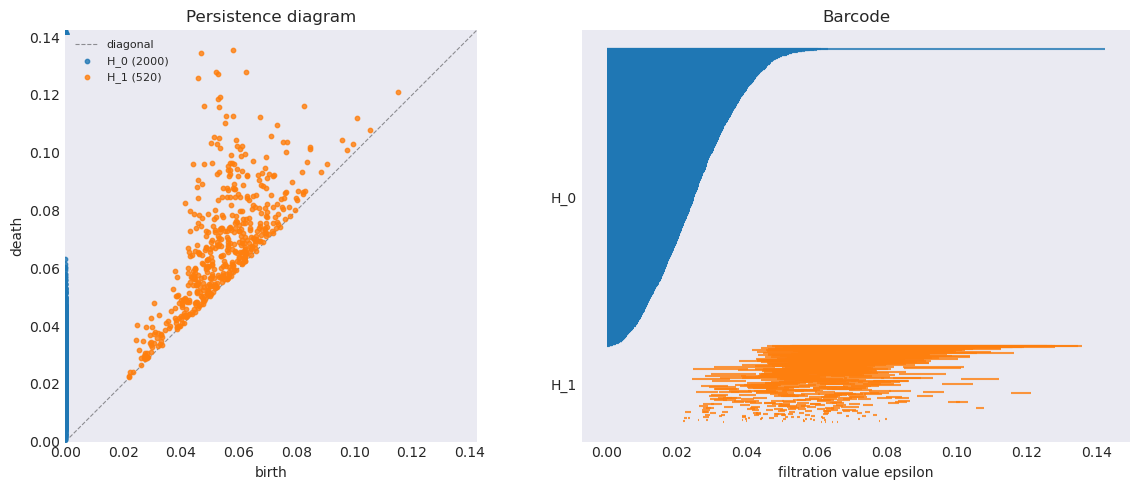

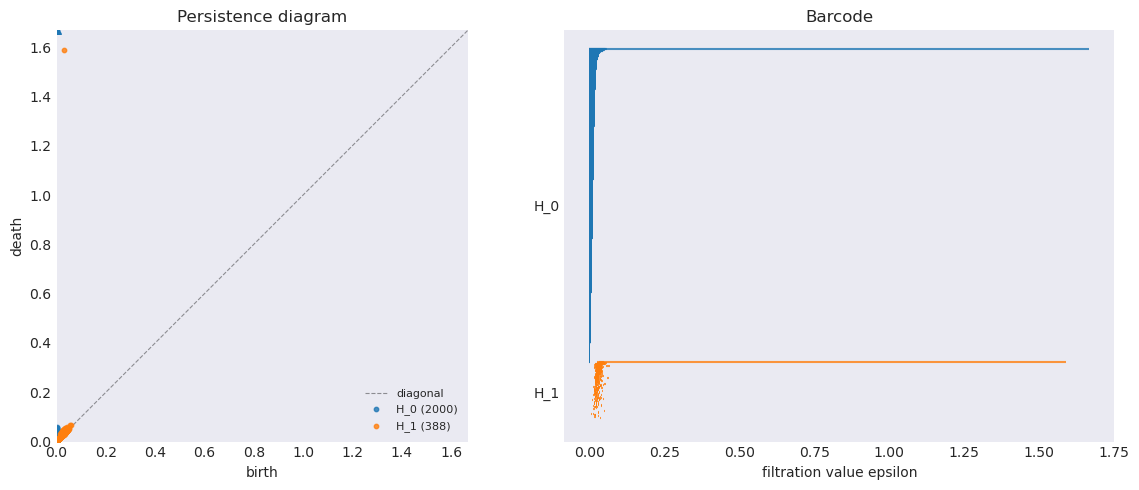

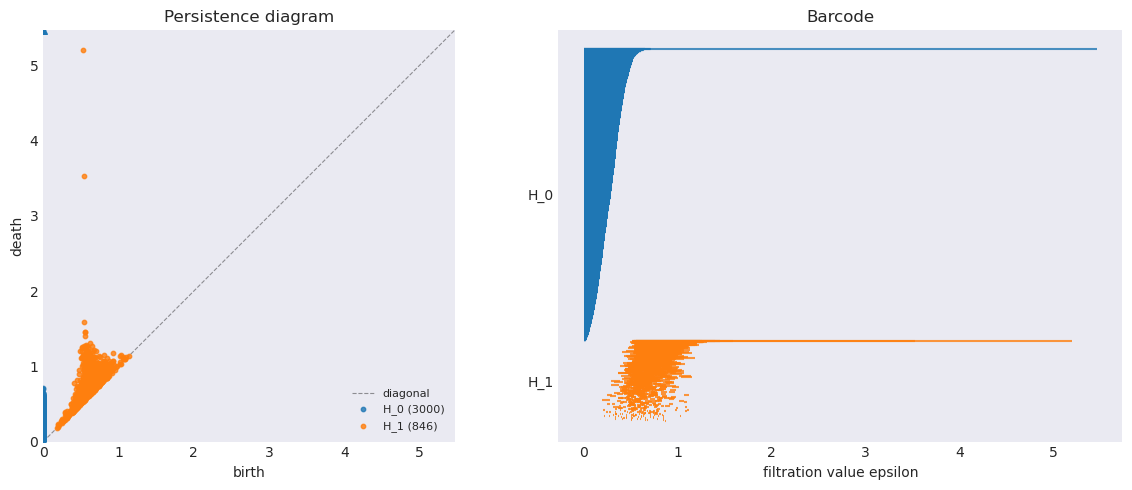

In [6]:
phantom_disk.display_dgms()
phantom_circle.display_dgms()
phantom_torus.display_dgms()

# Run hypothesis test on each

In [7]:
alpha      = 0.01

methods    = ["universal_null"]


phantom_disk.hypothesis_test(alpha, methods=methods, k=1)
phantom_circle.hypothesis_test(alpha,  methods=methods, k=1)
phantom_torus.hypothesis_test(alpha, methods=methods, k=1)

m: 520, k - number of rejections: 0
m: 388, k - number of rejections: 1
m: 846, k - number of rejections: 0


{'universal_null:median': {'results_array': array([[1.13206589, 1.13550234, 1.00303555, 0.9888451 , 0.        ],
         [1.09644878, 1.11729681, 1.01901414, 0.93266352, 0.        ],
         [1.08627021, 1.09227467, 1.00552759, 0.9798054 , 0.        ],
         ...,
         [0.19247426, 0.23759696, 1.23443497, 0.45864391, 0.        ],
         [0.19067639, 0.19186449, 1.00623097, 0.97727293, 0.        ],
         [0.18191986, 0.18448254, 1.0140869 , 0.94954544, 0.        ]],
        shape=(846, 5)),
  'threshold': inf}}

# Display hypothesis test results via signifiance persistence diagrams

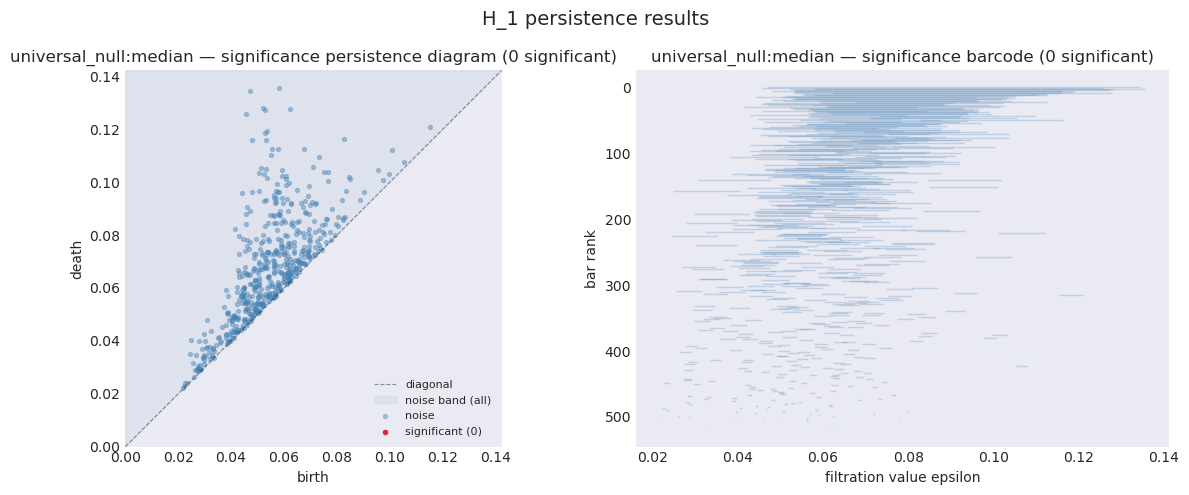

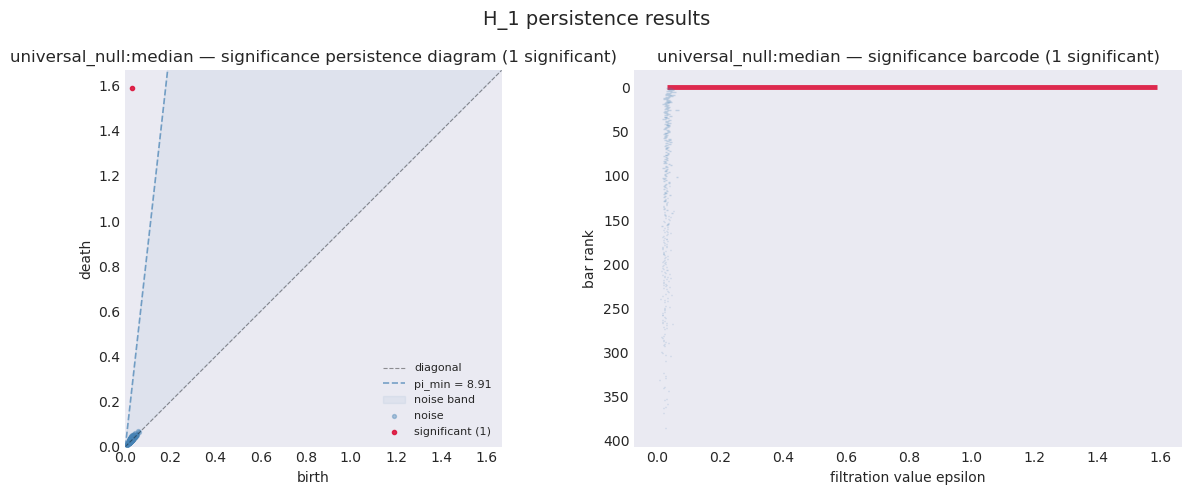

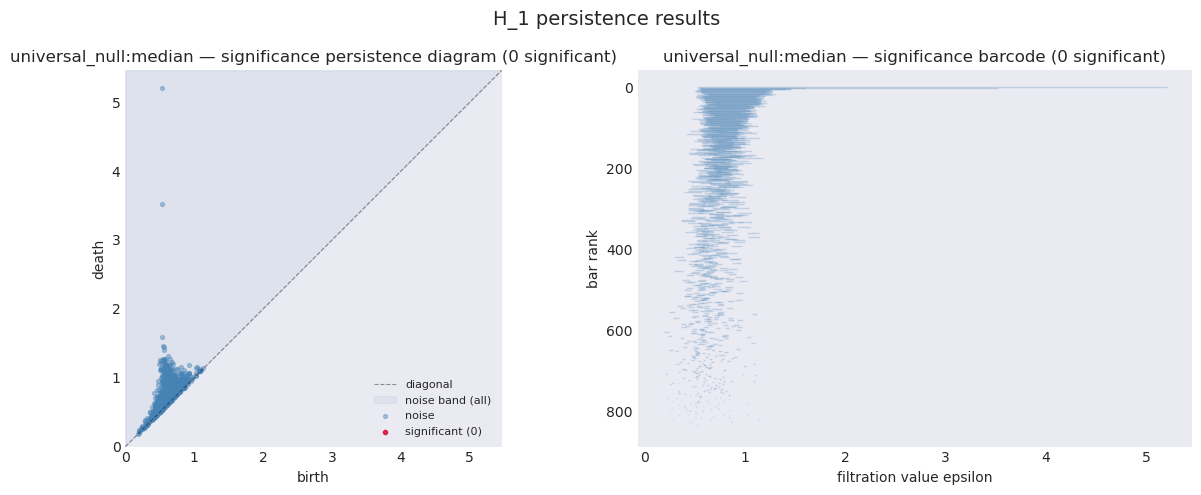

In [8]:
phantom_disk.display_results()
phantom_circle.display_results()
phantom_torus.display_results()